# Customer Churn Intelligence Platform

##Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

##Load Dataset

In [2]:
df=pd.read_csv('Telco_customer_churn.csv')

In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


##Dataset Shape and Information

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 33


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
df['Total Charges'].dtype

dtype('O')

In [7]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [8]:
df.columns.tolist()

['CustomerID',
 'Count',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Reason']

##Missing values

In [9]:
df.isnull().sum().sort_values(ascending=False)

,0
Churn Reason,5174
Total Charges,11
CustomerID,0
Count,0
Country,0
Zip Code,0
Lat Long,0
State,0
City,0
Gender,0


##Duplicate Records

In [10]:
df.duplicated().sum()

np.int64(0)

##Remove Data Leakage Features

In [11]:
drop_cols=['CustomerID','Count','Churn Value','Churn Score','CLTV','Churn Reason']
df=df.drop(columns=drop_cols)

In [12]:
df.shape

(7043, 27)

## Missing Value Check

In [13]:
df.isnull().sum().sort_values(ascending=False)

,0
Total Charges,11
State,0
Country,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0
Senior Citizen,0
Partner,0


No missing values were found after removing the Churn Reason column.

#Exploratory Data Analysis(EDA)

## Target Variable Distribution

In [14]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


In [15]:
(df['Churn Label'].value_counts(normalize=True)*100)

,proportion
Churn Label,
No,73.463013
Yes,26.536987


## Churn Distribution Plot

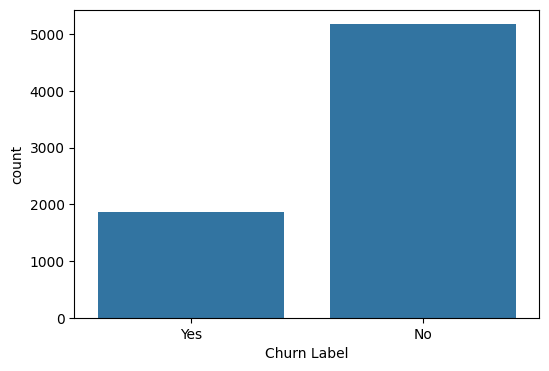

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn Label',
    data=df
)

plt.show()

Observation  
The plot compares the number of churned and non-churned customers.
Non-churned customers are likely more numerous than churned customers.

Business Insight  
Most customers remain with the company, while a smaller group churns.
Understanding the characteristics of churned customers can help the company improve retention strategies and reduce customer loss.

## Numerical Features Summary

In [17]:
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges']
df[num_cols].describe()

,Tenure Months,Monthly Charges,Total Charges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


## Tenure Distribution

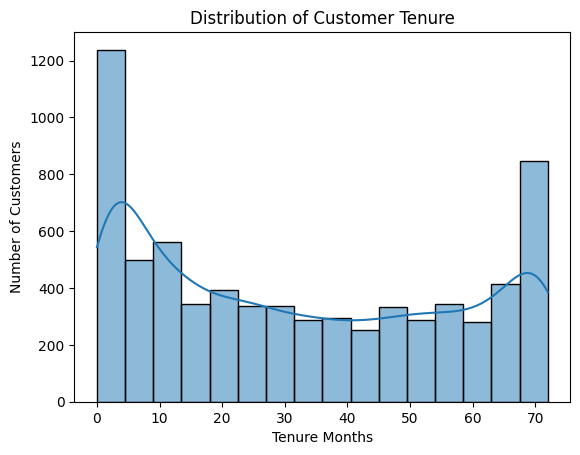

In [18]:
sns.histplot(df['Tenure Months'], kde=True)
plt.xlabel("Tenure Months")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Tenure")
plt.show()

Observation:

The tenure distribution is U-shaped, with a high concentration of customers in the early months (0–5) and the later months (65–72).
Relatively fewer customers fall within the middle tenure range.

Business Insight:

The customer base consists of both newly acquired and long-term loyal customers.
New customers may be more susceptible to churn and require targeted onboarding and engagement strategies.
Long-tenure customers appear more stable, highlighting the importance of retaining customers during their initial months of service.

## Monthly Charges Distribution

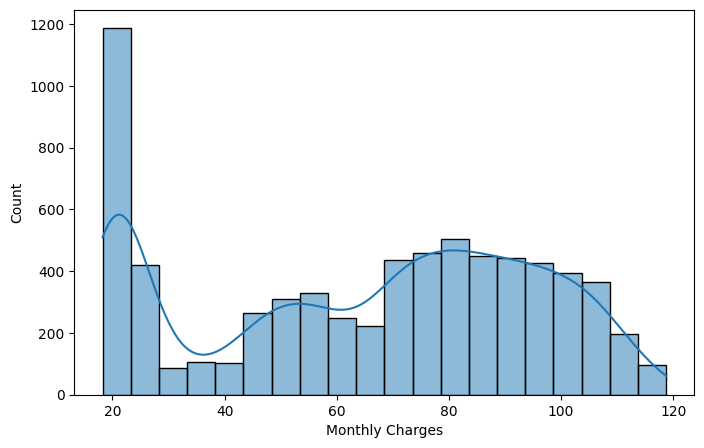

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Monthly Charges'],
    bins=20,
    kde=True
)
plt.show()


Observation:

Monthly Charges show a bimodal distribution, with customer concentrations in both low and high charge ranges.

Business Insight:

The presence of distinct pricing segments suggests that customer behavior and churn risk may vary across plans.

## Total Charges Distribution

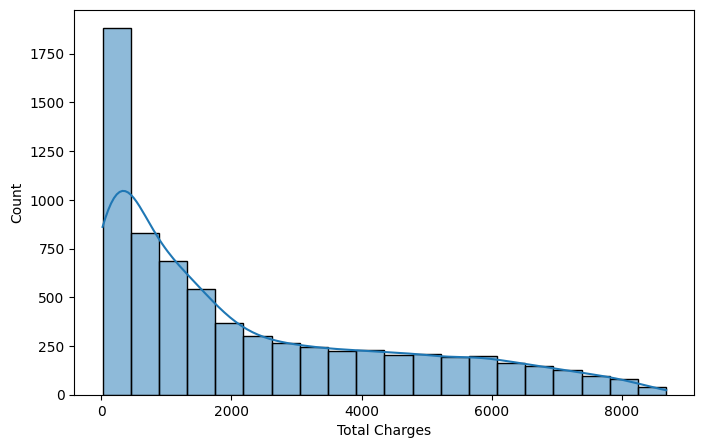

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Total Charges'],
    bins=20,
    kde=True
    )
plt.show()

Observation:  
Total Charges are right-skewed, with most customers having lower total charges and fewer customers having very high total charges.

Business Insight:  
Most customers have accumulated lower total charges, indicating a large proportion of relatively newer customers.
Customers with higher total charges are likely long-term customers and may represent higher lifetime value.

## Churn vs Tenure Months

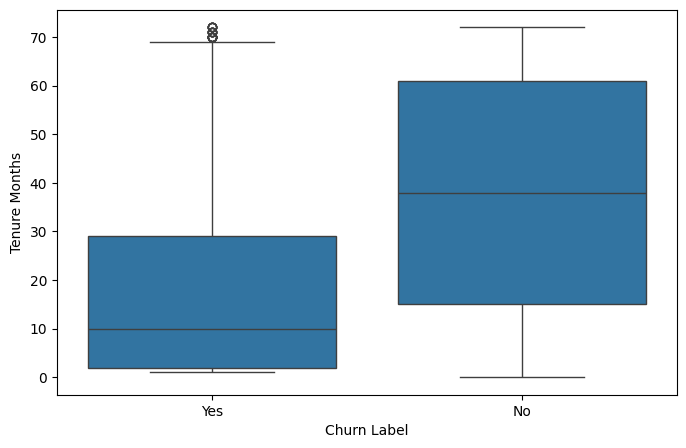

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn Label',
    y='Tenure Months',
    data=df
)
plt.show()


Observation:

Customers who churned (Yes) generally have much lower tenure than customers who did not churn (No).
The median tenure of non-churned customers is significantly higher.

Business Insight:

Customers with longer tenure are more likely to stay with the company.
Customer retention efforts should focus on the early months of the customer lifecycle, where churn risk appears to be higher.

## Churn vs Monthly Charges

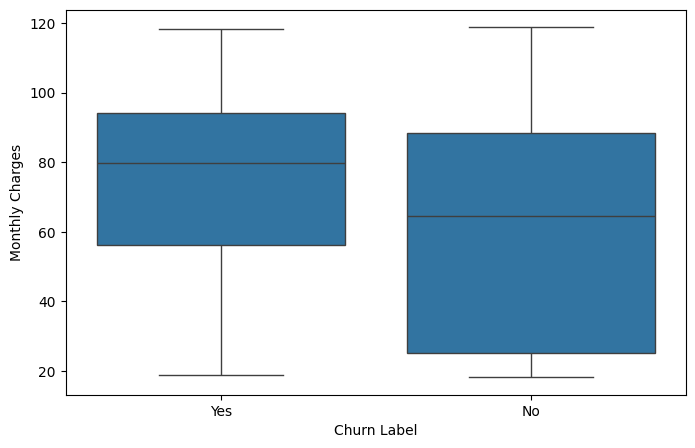

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn Label',
    y='Monthly Charges',
    data=df
)

plt.show()

Observation:

Customers who churned (Yes) tend to have higher monthly charges than customers who did not churn (No).
The median monthly charge is noticeably higher for churned customers.

Business Insight:

Higher monthly charges may be associated with a greater likelihood of churn.
The company may need to review pricing, service value, or retention strategies for higher-paying customers.

## Churn vs Total Charges

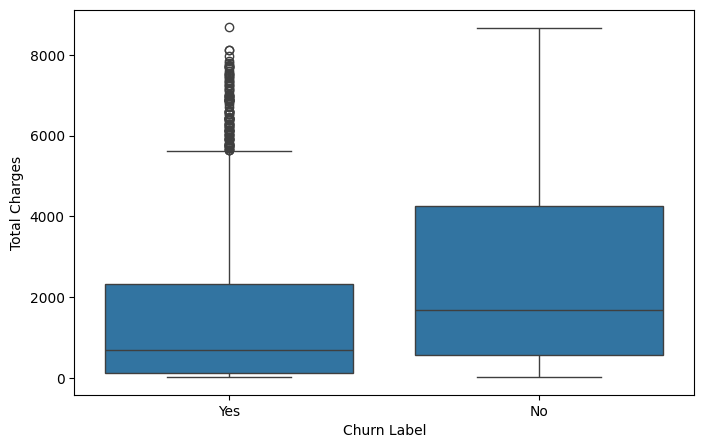

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn Label',
    y='Total Charges',
    data=df
)

plt.show()


Key Insight: High-Value Customer Vulnerability        

Analysis revealed that customer churn is heavily concentrated among high-spending tiers. The median total charges for churned accounts significantly exceed those of retained customers, indicating a critical revenue risk. This suggests a potential gap in pricing perception or ROI realization for top-tier clients, signaling an immediate need for targeted premium retention strategies.

## Contract vs Churn

In [24]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn Label'],
    normalize='index'
)
contract_churn


Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


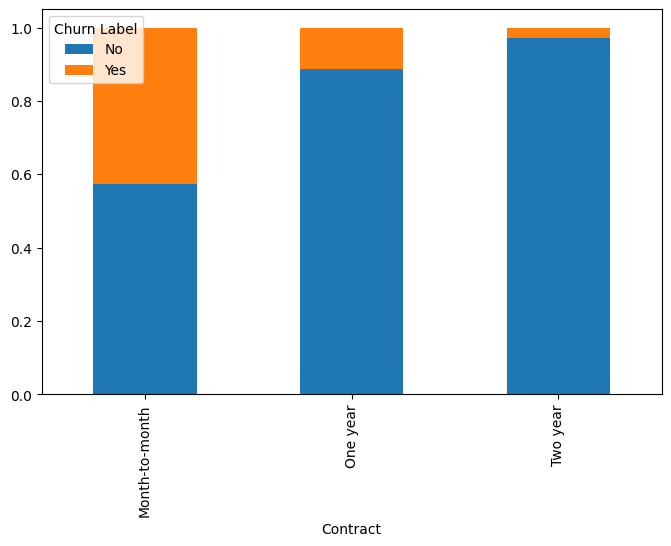

In [25]:
contract_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.show()

Business Insight

Customers with longer contracts are significantly less likely to churn.
Month-to-month customers represent the highest churn risk and should be a primary focus of retention efforts.


## Internet Service vs Churn

In [26]:
internet_churn = pd.crosstab(
    df['Internet Service'],
    df['Churn Label'],
    normalize='index'
)
internet_churn

Churn Label,No,Yes
Internet Service,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


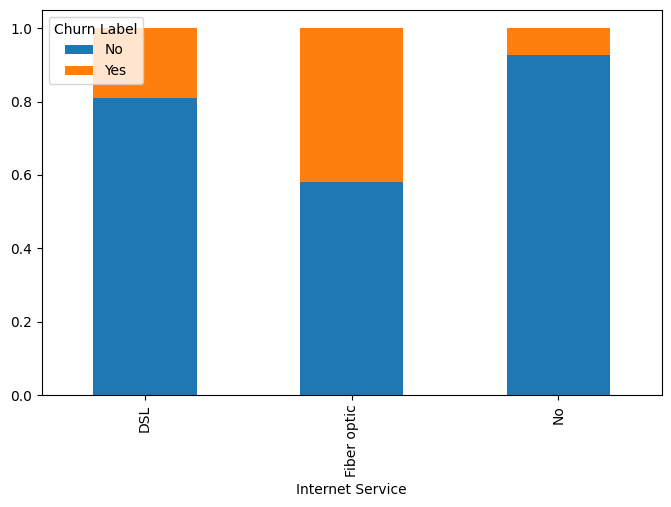

In [27]:
internet_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.show()

Observation:

Fiber optic customers have the highest churn rate (41.9%), followed by DSL customers (19.0%).   
Customers without internet service have the lowest churn rate (7.4%).

Business Insight:

Fiber optic customers are significantly more likely to churn, indicating potential issues related to pricing, service quality, or customer expectations.   
The company should investigate and improve the experience of Fiber optic customers to reduce churn.

## Payment Method vs Churn

In [28]:
payment_churn = pd.crosstab(
    df['Payment Method'],
    df['Churn Label'],
    normalize='index'
)

payment_churn

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


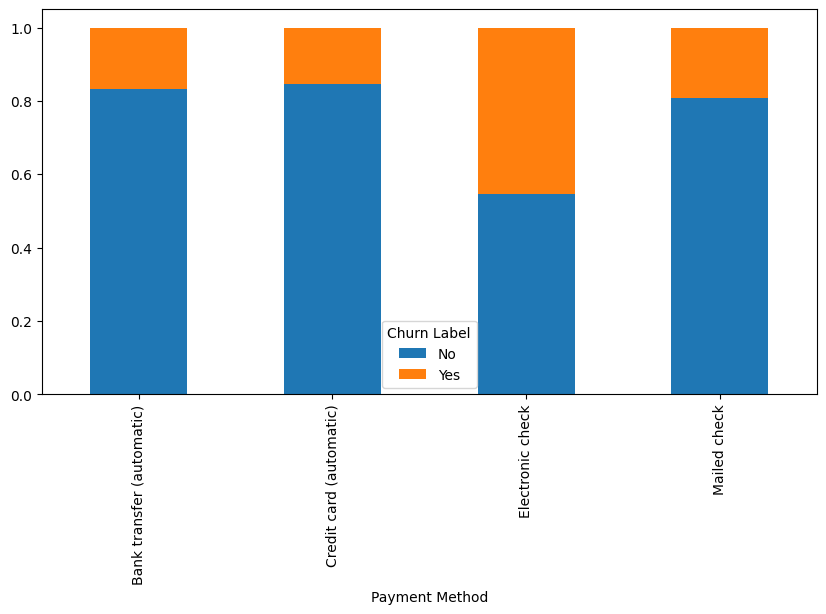

In [29]:
payment_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(10,5)
)

plt.show()

Observation:

Customers using Electronic Check have the highest churn rate (45.3%).
Customers using automatic payment methods have the lowest churn rates (15–17%).

Business Insight:

Customers who use Electronic Check are significantly more likely to churn.
Encouraging customers to switch to automatic payment methods may help improve retention and reduce churn.

In [30]:
df['Target']= df['Churn Label'].map({
    'No':0,
    'Yes':1
})

## Correlation Matrix

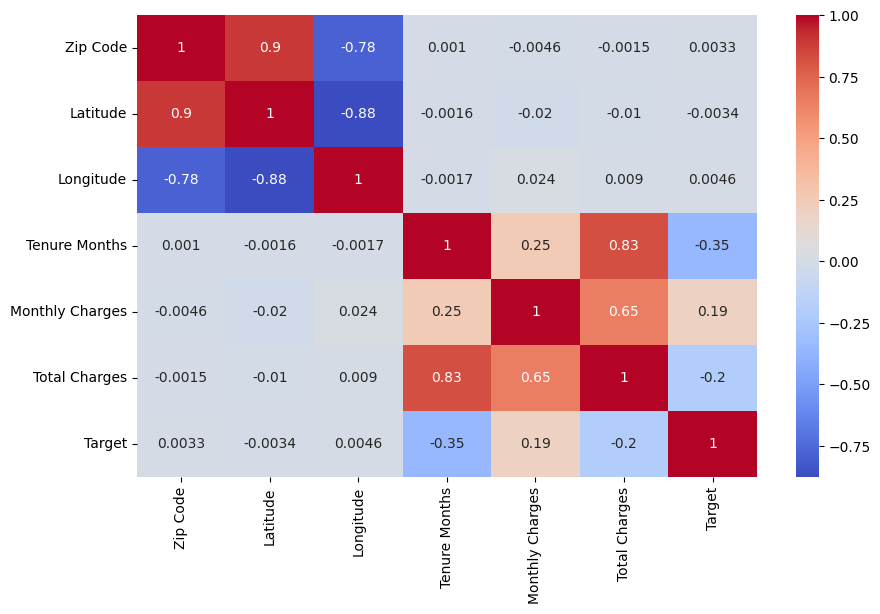

In [31]:
numeric_df= df.select_dtypes(
    include=['int64', 'float64']
)
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

## Key Findings

- Customers with low tenure are more likely to churn.
- Month-to-month contracts show the highest churn.
- Higher monthly charges are associated with increased churn.
- Payment method and internet service type influence churn behavior.
- Tenure and billing-related features are important predictors.

# Feature Engineering

##Total Additional Services

In [32]:
services_cols = ['Online Security',
                 'Online Backup',
                 'Device Protection',
                 'Tech Support',
                 'Streaming TV',
                 'Streaming Movies']
for col in services_cols:
    df[col] = np.where( df[col]== 'Yes',1,0
    )
df['Total Services'] = df[services_cols].sum(axis=1)

##Security Services

In [33]:
security_cols = ['Online Security',
                 'Online Backup',
                 'Device Protection',
                 'Tech Support']
df['Security Services Count']= df[security_cols].sum(axis=1)

##Streaming Services

In [34]:
stream_cols = [
    'Streaming TV',
    'Streaming Movies'
]

df['Streaming Services Count'] = df[stream_cols].sum(axis=1)

##Tenure Group

In [35]:
df['Tenure Group'] = pd.cut(
    df['Tenure Months'],
    bins=[0,12,24,48,72],
    labels=[
        '0-12',
        '12-24',
        '24-48',
        '48-72'
    ]
)

##Average Revenue Per Month

In [36]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].fillna(0)
df['Avg Revenue Per Month'] = (
    df['Total Charges']
    /
    (df['Tenure Months'] + 1)
)

Adding 1 to avoid 0 in the denominator

In [37]:
df[['Total Services',
     'Security Services Count',
     'Streaming Services Count',
      'Tenure Group',
      'Avg Revenue Per Month'
     ]].head()

,Total Services,Security Services Count,Streaming Services Count,Tenure Group,Avg Revenue Per Month
0,2,2,0,0-12,36.050000
1,0,0,0,0-12,50.550000
2,3,1,2,0-12,91.166667
3,4,2,2,24-48,105.036207
4,4,2,2,48-72,100.726000


In [38]:
df.columns.tolist()

['Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Target',
 'Total Services',
 'Security Services Count',
 'Streaming Services Count',
 'Tenure Group',
 'Avg Revenue Per Month']

In [39]:
df['Online Security'].unique()

array([1, 0])

In [40]:
df['Country'].nunique()

1

In [41]:
df['State'].nunique()

1

In [42]:
df['City'].nunique()

1129

In [43]:
df.drop(columns=['Country','State'],inplace=True)

##Check if feature engineering worked

In [44]:
df[['Total Services',
    'Security Services Count',
    'Streaming Services Count',
    'Avg Revenue Per Month']].describe()

,Total Services,Security Services Count,Streaming Services Count,Avg Revenue Per Month
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,2.037910,1.265654,0.772256,58.990789
std,1.847682,1.286879,0.852573,30.579745
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,26.041493
50%,2.000000,1.000000,0.000000,60.937879
75%,3.000000,2.000000,2.000000,84.830742
max,6.000000,4.000000,2.000000,118.969863


In [45]:
df['Tenure Group'].value_counts()

,count
Tenure Group,
48-72,2239
0-12,2175
24-48,1594
12-24,1024


In [46]:
df.to_csv(
    "feature_engineered_data.csv",
    index=False
)

#Preprocessing

In [47]:
X= df.drop('Target', axis=1)
X.dtypes


,0
City,object
Zip Code,int64
Lat Long,object
Latitude,float64
Longitude,float64
Gender,object
Senior Citizen,object
Partner,object
Dependents,object
Tenure Months,int64


## Import Libraries

In [48]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

## Load Feature Engineered Dataset

In [49]:
df = pd.read_csv("feature_engineered_data.csv")

df.head()

,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Target,Total Services,Security Services Count,Streaming Services Count,Tenure Group,Avg Revenue Per Month
0,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,1,1,0,0,0,0,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,2,2,0,0-12,36.050000
1,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,0,0,0,0,0,0,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0,0,0,0-12,50.550000
2,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,0,0,1,0,1,1,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,3,1,2,0-12,91.166667
3,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,0,0,1,1,1,1,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,4,2,2,24-48,105.036207
4,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,0,1,1,0,1,1,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,4,2,2,48-72,100.726000


## Remove Unnecessary Columns

In [50]:
drop_cols = [
    'City',
    'Zip Code',
    'Lat Long',
    'Churn Label'
]

df = df.drop(columns=drop_cols)

## Verify Remaining Columns

In [51]:
df.columns.tolist()

['Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Target',
 'Total Services',
 'Security Services Count',
 'Streaming Services Count',
 'Tenure Group',
 'Avg Revenue Per Month']

In [52]:
df = df.drop(columns=['Latitude', 'Longitude'])

## Split Features and Target

In [53]:
X = df.drop('Target', axis=1)

y = df['Target']

In [54]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (7043, 24)
y Shape: (7043,)


## Identify Feature Types

In [55]:
categorical_cols = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numerical_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

In [56]:
print("Categorical Columns")
print(categorical_cols)

print("\nNumerical Columns")
print(numerical_cols)

Categorical Columns
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Contract', 'Paperless Billing', 'Payment Method', 'Tenure Group']

Numerical Columns
['Tenure Months', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Monthly Charges', 'Total Charges', 'Total Services', 'Security Services Count', 'Streaming Services Count', 'Avg Revenue Per Month']


## Train-Test Split

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [58]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 24)
X_test : (1409, 24)
y_train: (5634,)
y_test : (1409,)


In [59]:
print(y_train.value_counts(normalize=True))

print("\n")

print(y_test.value_counts(normalize=True))

Target
0    0.734647
1    0.265353
Name: proportion, dtype: float64


Target
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [60]:
X_train.shape
X_test.shape

(1409, 24)

In [61]:
y_train.value_counts(normalize=True)

,proportion
Target,
0,0.734647
1,0.265353


# Create Preprocessing Pipeline

##Numerical Pipeline

In [62]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

numeric_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

##Categorical Pipeline

In [63]:
from sklearn.preprocessing import OneHotEncoder

categorical_transformer = Pipeline(
    steps=[
        (
            'onehot',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ]
)

##Column Transformer

In [64]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            numerical_cols
        ),
        (
            'cat',
            categorical_transformer,
            categorical_cols
        )
    ]
)

##Fit and Transform

In [65]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

##Check Shapes

In [66]:
print(X_train_processed.shape)

print(X_test_processed.shape)

(5634, 43)
(1409, 43)


# Logistic Regression Baseline Model

In [67]:
from sklearn.linear_model import LogisticRegression

##Train Model

In [68]:
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(
    X_train_processed,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

##Predictions

In [69]:
y_pred = lr.predict(X_test_processed)

y_prob = lr.predict_proba(
    X_test_processed
)[:,1]

##Evaluation

In [70]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [71]:
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    "Precision:",
    precision_score(y_test, y_pred)
)

print(
    "Recall:",
    recall_score(y_test, y_pred)
)

print(
    "F1:",
    f1_score(y_test, y_pred)
)

print(
    "ROC AUC:",
    roc_auc_score(y_test, y_prob)
)

Accuracy: 0.8026969481902059
Precision: 0.6509433962264151
Recall: 0.553475935828877
F1: 0.5982658959537572
ROC AUC: 0.8529799271487251


##Confusion Matrix

In [72]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[924 111]
 [167 207]]


##Classification Report

In [73]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



### Logistic Regression Results

The Logistic Regression model achieved an accuracy of 80.27% and a ROC-AUC score of 85.30%.

While the model performed well overall, it achieved a recall of 55.35% for churned customers, indicating that nearly half of the churners were missed.

This model serves as a strong baseline for comparison with more advanced models.

# Decision Tree Classifier

In [74]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train_processed,
    y_train
)


DecisionTreeClassifier(random_state=42)

##Predictions

In [75]:
y_pred_dt = dt.predict(X_test_processed)

y_prob_dt = dt.predict_proba(
    X_test_processed
)[:,1]

##Evaluation

In [76]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print("Precision:",
      precision_score(y_test, y_pred_dt))

print("Recall:",
      recall_score(y_test, y_pred_dt))

print("F1:",
      f1_score(y_test, y_pred_dt))

print("ROC AUC:",
      roc_auc_score(y_test, y_prob_dt))

Accuracy: 0.730305180979418
Precision: 0.49242424242424243
Recall: 0.5213903743315508
F1: 0.5064935064935064
ROC AUC: 0.6631313131313131


##Classification Report

In [77]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1035
           1       0.49      0.52      0.51       374

    accuracy                           0.73      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.74      0.73      0.73      1409



The Decision Tree model exhibited signs of overfitting, achieving significantly lower test performance than Logistic Regression.

The ROC-AUC score decreased from 0.853 to 0.663, indicating weaker discrimination between churners and non-churners.

# Random Forest Classifier

In [78]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_processed,
    y_train
)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

##Predictions

In [79]:
y_pred_rf = rf.predict(X_test_processed)

y_prob_rf = rf.predict_proba(
    X_test_processed
)[:,1]

##Evaluation

In [80]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1:",
      f1_score(y_test, y_pred_rf))

print("ROC AUC:",
      roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.7885024840312278
Precision: 0.6241830065359477
Recall: 0.5106951871657754
F1: 0.5617647058823529
ROC AUC: 0.8320997700793097


##Classification Report

In [81]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



## Model Comparison

Three machine learning models were evaluated for customer churn prediction.

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|---------|---------|---------|---------|---------|---------|
| Logistic Regression | 80.27% | 65.09% | 55.35% | 59.83% | 85.30% |
| Decision Tree | 73.03% | 49.24% | 52.14% | 50.65% | 66.31% |
| Random Forest | 78.85% | 62.42% | 51.07% | 56.18% | 83.21% |

### Key Findings

- Logistic Regression achieved the best overall performance.
- Decision Tree showed signs of overfitting and performed poorly on unseen data.
- Random Forest improved upon Decision Tree but did not outperform Logistic Regression.
- The ROC-AUC score of 85.30% indicates that Logistic Regression effectively distinguishes churning and non-churning customers.
- Recall remains relatively low, suggesting that many churning customers are still being missed.

# Handle Class Imbalance (SMOTE)


The dataset is imbalanced, with significantly fewer churned customers than non-churned customers.

To improve churn detection (Recall), SMOTE will be applied to balance the training data before retraining the models.

In [82]:

pip install imbalanced-learn

In [83]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

In [84]:
print(y_train_smote.value_counts())

Target
0    4139
1    4139
Name: count, dtype: int64


### Class Distribution After SMOTE

After applying SMOTE, both classes are now perfectly balanced.

- Class 0 (No churn): 4139 samples  
- Class 1 (Churn): 4139 samples  

This ensures the model does not get biased toward the majority class and improves fairness in prediction.

##Retrain Logistic Regression (After SMOTE)

Now we retrain Logistic Regression using the SMOTE-balanced training data.  
This helps the model learn both classes equally.

##Train Logistic Regression

In [85]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000)

##Predictions using Logistic Regression

In [86]:
y_pred_log = log_model.predict(X_test_processed)

##Model Evaluation (Logistic Regression)
We check accuracy, precision, recall, F1-score, and confusion matrix.

In [87]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

Accuracy: 0.7501774308019872
Precision: 0.5197132616487455
Recall: 0.7754010695187166
F1 Score: 0.6223175965665236

Confusion Matrix:
 [[767 268]
 [ 84 290]]


##Decision Tree (After SMOTE)

Now we train a Decision Tree model on the SMOTE-balanced dataset and evaluate its performance.

In [88]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_smote, y_train_smote)

DecisionTreeClassifier(random_state=42)

##Predictions using Decision Tree

In [89]:
y_pred_dt = dt_model.predict(X_test_processed)

##Model Evaluation (Decision Tree)
We evaluate accuracy, precision, recall, F1-score, and confusion matrix.

In [90]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.7281760113555713
Precision: 0.48931116389548696
Recall: 0.5508021390374331
F1 Score: 0.5182389937106918

Confusion Matrix:
 [[820 215]
 [168 206]]


##Random Forest (After SMOTE)

Now we train a Random Forest model on the SMOTE-balanced dataset and evaluate its performance.  
Random Forest usually performs better than a single Decision Tree because it reduces overfitting.

In [91]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

##Predictions using Random Forest

In [92]:
y_pred_rf = rf_model.predict(X_test_processed)

##Model Evaluation (Random Forest)
We evaluate accuracy, precision, recall, F1-score, and confusion matrix.

In [93]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.78708303761533
Precision: 0.6033519553072626
Recall: 0.5775401069518716
F1 Score: 0.5901639344262295

Confusion Matrix:
 [[893 142]
 [158 216]]


##XGBoost Model (After SMOTE)

Now we train an XGBoost model on the SMOTE-balanced dataset.  
XGBoost is a powerful boosting algorithm that usually gives the best performance for classification problems like churn prediction.

In [94]:
from xgboost import XGBClassifier

In [95]:
xgb_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_smote, y_train_smote)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:14:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

##Predictions using XGBoost

In [96]:
y_pred_xgb = xgb_model.predict(X_test_processed)

##Model Evaluation (XGBoost)
We evaluate accuracy, precision, recall, F1-score, and confusion matrix.

In [97]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.7892122072391767
Precision: 0.6049046321525886
Recall: 0.5935828877005348
F1 Score: 0.5991902834008097

Confusion Matrix:
 [[890 145]
 [152 222]]


##Model Comparison

Now we compare all models to select the best one based on performance metrics like Accuracy, Precision, Recall, and F1-score.

In [98]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.750177,0.519713,0.775401,0.622318
1,Decision Tree,0.728176,0.489311,0.550802,0.518239
2,Random Forest,0.787083,0.603352,0.577540,0.590164
3,XGBoost,0.789212,0.604905,0.593583,0.599190


##Best Model Selection

From the comparison table, we select the model with the best F1-score (important for churn prediction).

In [99]:
best_model = results.loc[results["F1 Score"].idxmax()]
best_model

,0
Model,Logistic Regression
Accuracy,0.750177
Precision,0.519713
Recall,0.775401
F1 Score,0.622318


##Feature Importance

Feature importance helps us understand which features are most responsible for predicting customer churn.  
Here we use the trained XGBoost model.

In [100]:
import matplotlib.pyplot as plt

importances = xgb_model.feature_importances_
features = preprocessor.get_feature_names_out() # Corrected line

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
})

feat_df = feat_df.sort_values(by="Importance", ascending=False)

feat_df

,Feature,Importance
29,cat__Contract_Month-to-month,0.282654
27,cat__Internet Service_Fiber optic,0.108776
19,cat__Dependents_No,0.079007
33,cat__Paperless Billing_Yes,0.067235
38,cat__Tenure Group_0-12,0.051883
36,cat__Payment Method_Electronic check,0.038720
28,cat__Internet Service_No,0.027168
41,cat__Tenure Group_48-72,0.026345
23,cat__Multiple Lines_No,0.018453
40,cat__Tenure Group_24-48,0.017017


##Top Feature Importance Plot

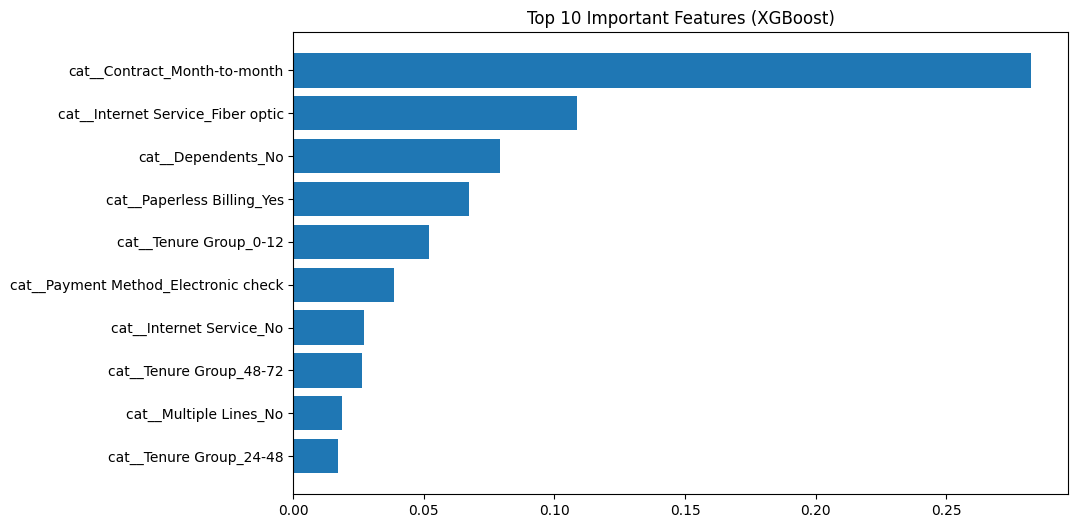

In [101]:
plt.figure(figsize=(10,6))
plt.barh(feat_df["Feature"][:10], feat_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features (XGBoost)")
plt.show()

##Hyperparameter Tuning (XGBoost)

Now we tune XGBoost hyperparameters to improve model performance using RandomizedSearchCV.

In [102]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, eval_metric='logloss')

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=10,
    scoring="f1",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_smote, y_train_smote)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='f1', verbose=1)

In [103]:
best_xgb = search.best_estimator_
print(search.best_params_)

{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


##Evaluation of Tuned Model

In [104]:
y_pred_tuned = best_xgb.predict(X_test_processed)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall:", recall_score(y_test, y_pred_tuned))
print("F1 Score:", f1_score(y_test, y_pred_tuned))

Accuracy: 0.7693399574166075
Precision: 0.5507246376811594
Recall: 0.7112299465240641
F1 Score: 0.6207701283547258


##SHAP Explainability

SHAP (Shapley Additive explanations) helps us understand how each feature contributes to individual predictions as well as overall model behavior.

In [105]:

import shap

In [106]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_processed)

##SHAP Summary Plot
This shows how each feature affects model predictions globally.

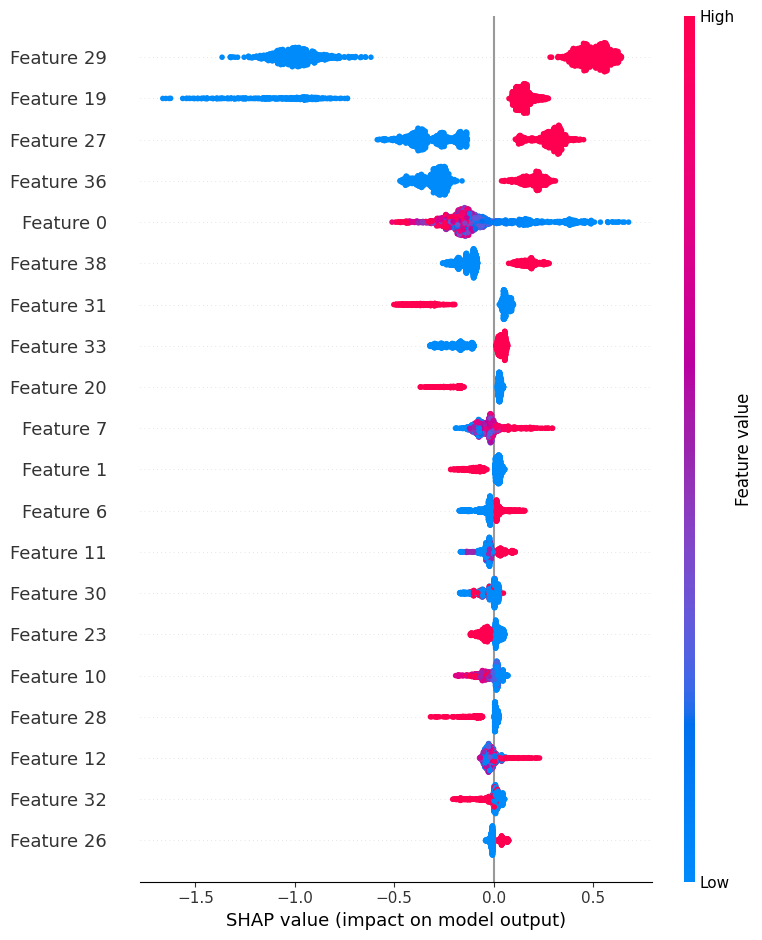

In [107]:
shap.summary_plot(shap_values, X_test_processed)

## SHAP Insights

- Red points = high feature value
- Blue points = low feature value  
- Right side = increases churn probability  
- Left side = decreases churn probability  

##Individual Prediction Explanation
We explain why a single customer is predicted to churn or not.

In [108]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test_processed[0] # Changed from X_test.iloc[0] to X_test_processed[0]
)

In [109]:
X.columns.tolist()

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Total Services',
 'Security Services Count',
 'Streaming Services Count',
 'Tenure Group',
 'Avg Revenue Per Month']

In [110]:
for col in [
    'Gender',
    'Senior Citizen',
    'Partner',
    'Dependents',
    'Phone Service',
    'Multiple Lines',
    'Internet Service',
    'Contract',
    'Paperless Billing',
    'Payment Method'
]:
    print("\n", col)
    print(df[col].unique())


 Gender
['Male' 'Female']

 Senior Citizen
['No' 'Yes']

 Partner
['No' 'Yes']

 Dependents
['No' 'Yes']

 Phone Service
['Yes' 'No']

 Multiple Lines
['No' 'Yes' 'No phone service']

 Internet Service
['DSL' 'Fiber optic' 'No']

 Contract
['Month-to-month' 'Two year' 'One year']

 Paperless Billing
['Yes' 'No']

 Payment Method
['Mailed check' 'Electronic check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


# Model Deployment with Streamlit

## Save Model and Preprocessor

In [125]:
import joblib

joblib.dump(best_xgb, "model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

print("Files saved successfully.")

Files saved successfully.


## Verify Saved Files

In [126]:
import os

os.listdir()

['.config',
 'Telco_customer_churn.csv',
 'model.pkl',
 'requirements.txt',
 'feature_engineered_data.csv',
 'preprocessor.pkl',
 'app.py',
 'sample_data']

In [127]:
!pip install streamlit

Create app.py

In [128]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Load model and preprocessor
model = joblib.load("model.pkl")
preprocessor = joblib.load("preprocessor.pkl")

st.title("Customer Churn Intelligence Platform")

st.write("Predict whether a customer will churn or not.")

st.success("Model loaded successfully!")

Overwriting app.py


In [129]:
%%writefile app.py
st.header("Customer Information")

gender = st.selectbox("Gender", ["Male", "Female"])

senior_citizen = st.selectbox("Senior Citizen", ["No", "Yes"])

partner = st.selectbox("Partner", ["No", "Yes"])

dependents = st.selectbox("Dependents", ["No", "Yes"])

tenure_months = st.number_input(
    "Tenure Months",
    min_value=0,
    max_value=72,
    value=12
)

phone_service = st.selectbox(
    "Phone Service",
    ["Yes", "No"]
)

multiple_lines = st.selectbox(
    "Multiple Lines",
    ["No", "Yes", "No phone service"]
)

internet_service = st.selectbox(
    "Internet Service",
    ["DSL", "Fiber optic", "No"]
)

online_security = st.selectbox(
    "Online Security",
    ["Yes", "No"]
)

online_backup = st.selectbox(
    "Online Backup",
    ["Yes", "No"]
)

device_protection = st.selectbox(
    "Device Protection",
    ["Yes", "No"]
)

tech_support = st.selectbox(
    "Tech Support",
    ["Yes", "No"]
)

streaming_tv = st.selectbox(
    "Streaming TV",
    ["Yes", "No"]
)

streaming_movies = st.selectbox(
    "Streaming Movies",
    ["Yes", "No"]
)

contract = st.selectbox(
    "Contract",
    ["Month-to-month", "One year", "Two year"]
)

paperless_billing = st.selectbox(
    "Paperless Billing",
    ["Yes", "No"]
)

payment_method = st.selectbox(
    "Payment Method",
    [
        "Mailed check",
        "Electronic check",
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ]
)

monthly_charges = st.number_input(
    "Monthly Charges",
    min_value=0.0,
    value=50.0
)

total_charges = st.number_input(
    "Total Charges",
    min_value=0.0,
    value=500.0
)

# Feature Engineering

total_services = (
    (1 if online_security == "Yes" else 0)
    + (1 if online_backup == "Yes" else 0)
    + (1 if device_protection == "Yes" else 0)
    + (1 if tech_support == "Yes" else 0)
    + (1 if streaming_tv == "Yes" else 0)
    + (1 if streaming_movies == "Yes" else 0)
)

security_services_count = (
    (1 if online_security == "Yes" else 0)
    + (1 if online_backup == "Yes" else 0)
    + (1 if device_protection == "Yes" else 0)
    + (1 if tech_support == "Yes" else 0)
)

streaming_services_count = (
    (1 if streaming_tv == "Yes" else 0)
    + (1 if streaming_movies == "Yes" else 0)
)

if tenure_months <= 12:
    tenure_group = "0-12"
elif tenure_months <= 24:
    tenure_group = "12-24"
elif tenure_months <= 48:
    tenure_group = "24-48"
else:
    tenure_group = "48-72"

avg_revenue_per_month = total_charges / (tenure_months + 1)

if st.button("Predict Churn"):

    input_data = pd.DataFrame({
        'Gender': [gender],
        'Senior Citizen': [senior_citizen],
        'Partner': [partner],
        'Dependents': [dependents],
        'Tenure Months': [tenure_months],
        'Phone Service': [phone_service],
        'Multiple Lines': [multiple_lines],
        'Internet Service': [internet_service],
        'Online Security': [online_security],
        'Online Backup': [online_backup],
        'Device Protection': [device_protection],
        'Tech Support': [tech_support],
        'Streaming TV': [streaming_tv],
        'Streaming Movies': [streaming_movies],
        'Contract': [contract],
        'Paperless Billing': [paperless_billing],
        'Payment Method': [payment_method],
        'Monthly Charges': [monthly_charges],
        'Total Charges': [total_charges],
        'Total Services': [total_services],
        'Security Services Count': [security_services_count],
        'Streaming Services Count': [streaming_services_count],
        'Tenure Group': [tenure_group],
        'Avg Revenue Per Month': [avg_revenue_per_month]
    })

    processed_data = preprocessor.transform(input_data)

    prediction = model.predict(processed_data)[0]
    probability = model.predict_proba(processed_data)[0][1]

    st.subheader("Prediction Result")

    if prediction == 1:
        st.error("Customer is likely to Churn")
    else:
        st.success("Customer is likely to Stay")

    st.write(f"Churn Probability: {probability:.2%}")

Overwriting app.py


In [130]:
with open("app.py", "r") as f:
    print(f.read())

st.header("Customer Information")

gender = st.selectbox("Gender", ["Male", "Female"])

senior_citizen = st.selectbox("Senior Citizen", ["No", "Yes"])

partner = st.selectbox("Partner", ["No", "Yes"])

dependents = st.selectbox("Dependents", ["No", "Yes"])

tenure_months = st.number_input(
    "Tenure Months",
    min_value=0,
    max_value=72,
    value=12
)

phone_service = st.selectbox(
    "Phone Service",
    ["Yes", "No"]
)

multiple_lines = st.selectbox(
    "Multiple Lines",
    ["No", "Yes", "No phone service"]
)

internet_service = st.selectbox(
    "Internet Service",
    ["DSL", "Fiber optic", "No"]
)

online_security = st.selectbox(
    "Online Security",
    ["Yes", "No"]
)

online_backup = st.selectbox(
    "Online Backup",
    ["Yes", "No"]
)

device_protection = st.selectbox(
    "Device Protection",
    ["Yes", "No"]
)

tech_support = st.selectbox(
    "Tech Support",
    ["Yes", "No"]
)

streaming_tv = st.selectbox(
    "Streaming TV",
    ["Yes", "No"]
)

streaming_

In [121]:
with open("app.py", "r") as f:
    print(f.read()[-1000:])

ech Support': [tech_support],
        'Streaming TV': [streaming_tv],
        'Streaming Movies': [streaming_movies],
        'Contract': [contract],
        'Paperless Billing': [paperless_billing],
        'Payment Method': [payment_method],
        'Monthly Charges': [monthly_charges],
        'Total Charges': [total_charges],
        'Total Services': [total_services],
        'Security Services Count': [security_services_count],
        'Streaming Services Count': [streaming_services_count],
        'Tenure Group': [tenure_group],
        'Avg Revenue Per Month': [avg_revenue_per_month]
    })

    processed_data = preprocessor.transform(input_data)

    prediction = model.predict(processed_data)[0]
    probability = model.predict_proba(processed_data)[0][1]

    st.subheader("Prediction Result")

    if prediction == 1:
        st.error("Customer is likely to Churn")
    else:
        st.success("Customer is likely to Stay")

    st.write(f"Churn Probability: {probability:.2%}")


In [122]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
xgboost
joblib

Writing requirements.txt
